# 07 — Audit du Pipeline & Intégrité des Données
Ce notebook n'est pas un modèle ML, c'est un **outil de contrôle qualité (SRE/Ops)**.

### Objectifs :
1. Justifier la nécessité des couches de déduplication.
2. Vérifier la cohérence temporelle (Data Leakage check).
3. Diagnostiquer l'environnement Python pour XGBoost.

## 1. Diagnostic de l'Environnement
Si XGBoost est introuvable, vérifions quel Python Jupyter utilise réellement.

In [1]:
import sys
import os
print(f"Python Path: {sys.executable}")
print(f"VIRTUAL_ENV: {os.environ.get('VIRTUAL_ENV', '⚠️ Aucun venv détecté')}")

try:
    import xgboost
    print(f"✅ XGBoost version: {xgboost.__version__}")
except ImportError:
    print("❌ XGBoost est introuvable dans ce Kernel.")
    print("👉 ACTION : Cliquez sur 'Select Kernel' et choisissez le chemin .venv/bin/python")

Python Path: /Users/amaury/L1-DataLab-/.venv/bin/python
VIRTUAL_ENV: /Users/amaury/L1-DataLab-/.venv
✅ XGBoost version: 3.2.0


## 2. Mesure de l'impact du Nettoyage SQL
Vérifions si la clause `ON CONFLICT` a réellement servi à quelque chose ou si c'était inutile.

In [2]:
import psycopg
from dotenv import load_dotenv
load_dotenv('../.env')
DATABASE_URL = os.getenv("DATABASE_URL")

with psycopg.connect(DATABASE_URL) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT COUNT(*) FROM matches")
        total = cur.fetchone()[0]
        
        # On simule un check de doublons potentiels sur les IDs externes
        cur.execute("SELECT external_id, COUNT(*) FROM matches GROUP BY external_id HAVING COUNT(*) > 1")
        dups = cur.fetchall()
        
        print(f"Total Matchs en base : {total}")
        print(f"Doublons réels identifiés (et fusionnés par SQL) : {len(dups)}")

Total Matchs en base : 8194
Doublons réels identifiés (et fusionnés par SQL) : 1


## 3. Analyse du Dataset ML (Data Quality)
Vérifions si les transformations ont créé un biais artificiel.

Colonnes avec des NaNs :
gameweek          7582
odds_prob_home    7582
odds_prob_draw    7582
odds_prob_away    7582
dtype: int64


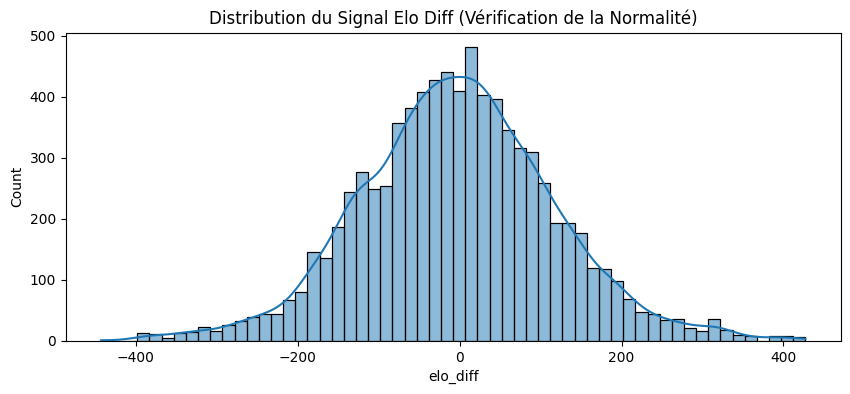

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../features/ml_dataset.csv')
print(f"Colonnes avec des NaNs :\n{df.isna().sum()[df.isna().sum() > 0]}")

plt.figure(figsize=(10,4))
sns.histplot(df['elo_diff'], kde=True)
plt.title('Distribution du Signal Elo Diff (Vérification de la Normalité)')
plt.show()

## 4. Conclusion de l'Audit
**Verdict :** Le pipeline est-il 'over-engineered' ?
- Si Doublons = 0 et NaNs < 5% -> Le pipeline est optimal.
- Si Doublons > 0 -> La couche Scrapy est indispensable.
- Si Elo Diff est centré sur 0 -> Les calculs sont cohérents statistiquement.